In [154]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

In [155]:
archivo_subido = files.upload()

nombre_archivo = list(archivo_subido.keys())[0]
contenido = archivo_subido[nombre_archivo]

df = pd.read_csv(
    io.BytesIO(contenido),
    sep="\t",
    decimal=",",
    encoding="latin1",
    engine="python"
)

df = df.dropna(axis=1, how="all")

datos = pd.DataFrame({
    "tiempo_s": pd.to_numeric(df.iloc[:, 2], errors="coerce"),
    "masa_g": pd.to_numeric(df.iloc[:, 3], errors="coerce")
}).dropna()

datos.head()

Saving 2-A.txt to 2-A (1).txt


,tiempo_s,masa_g
0,0.36,15.25
1,2.37,17.05
2,4.38,19.19
3,6.39,21.26
4,8.40,23.34


In [156]:
# Tiempo a partir del cual comienza el régimen lineal
t_inicio = float(input("Inicio del ajuste lineal [s]: "))

# Seleccionar únicamente los datos representativos
datos_ajuste = datos[
    datos["tiempo_s"] >= t_inicio
].copy()

if len(datos_ajuste) < 2:
    raise ValueError("No hay suficientes puntos para hacer el ajuste.")

# Ajuste lineal sobre los datos seleccionados
pendiente, intercepto = np.polyfit(
    datos_ajuste["tiempo_s"],
    datos_ajuste["masa_g"],
    1
)

datos_ajuste["masa_ajustada_g"] = (
    pendiente * datos_ajuste["tiempo_s"] + intercepto
)

# Caudal másico
dm_dt_g_s = abs(pendiente)
dm_dt_kg_s = dm_dt_g_s / 1000

# Coeficiente de determinación R²
masa_medida = datos_ajuste["masa_g"]
masa_calculada = datos_ajuste["masa_ajustada_g"]

ss_res = np.sum((masa_medida - masa_calculada)**2)
ss_tot = np.sum((masa_medida - masa_medida.mean())**2)

R2 = 1 - ss_res / ss_tot

print(f"Inicio del ajuste = {t_inicio:.2f} s")
print(f"dm/dt = {dm_dt_g_s:.6e} g/s")
print(f"R² = {R2:.6f}")

Inicio del ajuste lineal [s]: 15
Inicio del ajuste = 15.00 s
dm/dt = 1.041619e+00 g/s
R² = 0.999982


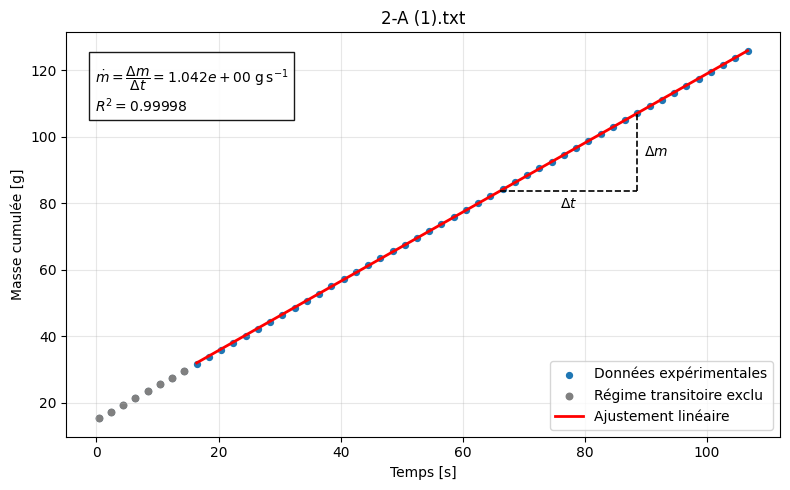

In [157]:
plt.figure(figsize=(8, 5))

# Todos los datos experimentales
plt.scatter(
    datos["tiempo_s"],
    datos["masa_g"],
    s=18,
    color="tab:blue",
    label="Données expérimentales"
)

# Puntos excluidos
datos_excluidos = datos[datos["tiempo_s"] < t_inicio]

plt.scatter(
    datos_excluidos["tiempo_s"],
    datos_excluidos["masa_g"],
    s=22,
    color="gray",
    label="Régime transitoire exclu"
)

# Ajuste solamente en la región lineal
plt.plot(
    datos_ajuste["tiempo_s"],
    datos_ajuste["masa_ajustada_g"],
    color="red",
    linewidth=2,
    label="Ajustement linéaire"
)

# Triángulo para mostrar la pendiente
t1 = datos_ajuste["tiempo_s"].quantile(0.55)
t2 = datos_ajuste["tiempo_s"].quantile(0.80)

m1 = pendiente * t1 + intercepto
m2 = pendiente * t2 + intercepto

plt.plot(
    [t1, t2],
    [m1, m1],
    "k--",
    linewidth=1.2
)

plt.plot(
    [t2, t2],
    [m1, m2],
    "k--",
    linewidth=1.2
)

plt.text(
    (t1 + t2) / 2,
    m1 - 0.04 * datos["masa_g"].max(),
    r"$\Delta t$",
    ha="center"
)

plt.text(
    t2 + 0.01 * datos["tiempo_s"].max(),
    (m1 + m2) / 2,
    r"$\Delta m$",
    va="center"
)

# Pendiente y R²
plt.text(
    0.04,
    0.92,
    rf"$\dot{{m}}=\dfrac{{\Delta m}}{{\Delta t}}"
    rf"={dm_dt_g_s:.3e}\ \mathrm{{g\,s^{{-1}}}}$"
    "\n"
    rf"$R^2={R2:.5f}$",
    transform=plt.gca().transAxes,
    va="top",
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        alpha=0.9
    )
)

plt.xlabel("Temps [s]")
plt.ylabel("Masse cumulée [g]")
plt.title(nombre_archivo)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [158]:
# Dimensiones de esta probeta
L_mm = 84.19    # Altura de la probeta (mm)
diametro_mm = 37.43  # Diámetro de la probeta (mm)
h_mm = 660        # Altura de agua (mm)

# Conversión a metros
L = L_mm / 1000
diametro = diametro_mm / 1000
h = h_mm / 1000

A = np.pi * (diametro / 2)**2

# Propiedades del agua
rho = 1000       # kg/m³
mu = 1.0e-3      # Pa·s
g = 9.81         # m/s²

# Gradiente de presión: rho*g*h/L
gradiente_p = rho * g * h / L

# Ley de Darcy
k_m2 = mu * dm_dt_kg_s / (rho * A * gradiente_p)

# Conversiones
k_D = k_m2 / 9.869233e-13
k_mD = k_D * 1000

print(f"Archivo: {nombre_archivo}")
print(f"dm/dt = {dm_dt_g_s:.6e} g/s")
print(f"Permeabilité: {k_m2:.6e} m²")
print(f"Permeabilité: {k_D:.6e} D")
print(f"Permeabilité: {k_mD:.6e} mD")

Archivo: 2-A (1).txt
dm/dt = 1.041619e+00 g/s
Permeabilité: 1.230912e-11 m²
Permeabilité: 1.247221e+01 D
Permeabilité: 1.247221e+04 mD
